In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
import sympy  as sp

In [2]:
class Newton_Raphson(TypedDict):
    equation: str
    max_iterations: int
    x0: float
    x: float
    x_previous: float
    iteration: int
    error: float
    tolerance: float

In [4]:
def Calculate_Approximation(state: Newton_Raphson):

    f = sp.sympify(state['equation'])
    x_symbol = sp.symbols('x')
    x_current = state['x']
    df = sp.diff(f, x_symbol )
    f_value = f.subs(x_symbol, x_current)
    df_value = df.subs(x_symbol, x_current)
    if df_value == 0:
        raise ValueError("Derivative is zero. Newton-Raphson cannot continue.")

    x_new = x_current - (f_value / df_value)

    return {
        'x_previous': x_current,
        'x': float(x_new),
        'iteration': state['iteration'] + 1
    }

In [5]:
def Check_Error(state: Newton_Raphson):
    error = abs(state['x'] - state['x_previous'])
    return {
        'error': float(error)
    }

In [6]:
def evaluator(state: Newton_Raphson):
    if state['error'] <= state['tolerance']:
        return 'No'
    elif state['iteration'] >= state['max_iterations']:
        return 'No'
    else:
        return 'Yes'

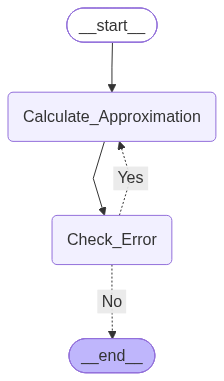

In [7]:
graph=StateGraph(Newton_Raphson)
#node
graph.add_node('Calculate_Approximation',Calculate_Approximation)
graph.add_node('Check_Error',Check_Error)
# graph.add_node('Optimization',Optimization)
#edge
graph.add_edge(START,'Calculate_Approximation')
graph.add_edge('Calculate_Approximation','Check_Error')
graph.add_conditional_edges('Check_Error',evaluator, {'No': END, 'Yes': 'Calculate_Approximation'})
# graph.add_edge('Check_Error',END)
workflow = graph.compile()

workflow

In [10]:
initial_state1 = {
    "equation": "x**3 - x - 2",
    "max_iterations": 5,
    "x0": 2.0,
    "x": 2.0,
    "x_previous": 2.0,
    "iteration": 0,
    "error": float('inf'),
    "tolerance": 1e-5
}
initial_state2 = {
    "equation": "x**2 - 4",
    "max_iterations": 10,
    "x0": 3.0,
    "x": 3.0,
    "x_previous": 3.0,
    "iteration": 0,
    "error": float('inf'),
    "tolerance": 1e-5
}
result=workflow.invoke(initial_state2)

In [13]:
result


{'equation': 'x**2 - 4',
 'max_iterations': 10,
 'x0': 3.0,
 'x': 2.0,
 'x_previous': 2.000000000026214,
 'iteration': 5,
 'error': 2.6214141968239346e-11,
 'tolerance': 1e-05}

In [14]:
print("Final Answer:", result["x"])

Final Answer: 2.0
